In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import sys
sys.path.append('..')
from src.utils import *
from src.metrics import *

In [3]:
filepath = '../datasets/ECG/MBA_ECG14046_data_0.out'
columns = ['value', 'anomaly']
df = pd.read_csv(filepath, header=None, names=columns).dropna().to_numpy()

print(df.shape)

max_length = 229900

data = df[:max_length,0].astype(float)
label = df[:max_length,1].astype(int)

(229900, 2)


In [6]:
with open('scores_lof.json', 'r') as file:
    lof_score = json.load(file)

In [13]:
with open('../data/ecg14046_0_scores_dict_tsb_full.json', 'r') as file:
    tsb_scores_dict = json.load(file)

In [14]:
tsb_scores_dict['LOF'] = lof_score

In [15]:
tsb_scores_dict.keys()

dict_keys(['IF', 'S2G', 'norma', 'PCA', 'SAND_OFF', 'POLY', 'OCSVM', 'AE', 'LOF'])

In [16]:
tsb_scores_dict['OCSVM'] = pd.Series(tsb_scores_dict['OCSVM']).ewm(alpha=0.4).mean().to_list()
tsb_scores_dict['AE'] = pd.Series(tsb_scores_dict['AE']).ewm(alpha=0.4).mean().to_list()

### Labels Compared with Raw Anomaly Scores

In [17]:
def plotter(label, tsb_scores_dict_820):
    fig, axs = plt.subplots(9, 1, sharex=True, figsize = (20, 10))
    index = range(len(label))


    axs[0].plot(index, label, color='blue', label='GTruth')
    #axs[8].plot(index, tsb_scores_dict_820['SAND_ON'], color='red', label='Predicted SAND Online')
    axs[8].plot(index, tsb_scores_dict_820['LOF'], color='green', label='Predicted LOF')
    axs[3].plot(index, tsb_scores_dict_820['S2G'], color='yellow', label='Predicted Series2Graph')
    axs[4].plot(index, tsb_scores_dict_820['norma'], color='black', label='Predicted Norma')
    axs[5].plot(index, tsb_scores_dict_820['SAND_OFF'], label='Predicted SAND Offline')
    axs[6].plot(index, tsb_scores_dict_820['AE'], label='Predicton AE')
    axs[7].plot(index, tsb_scores_dict_820['PCA'], label='Predicton PCA')
    axs[1].plot(index, tsb_scores_dict_820['POLY'], label='Predicton POLY')
    axs[2].plot(index, tsb_scores_dict_820['OCSVM'], label='Predicton OCSVM')

    axs[0].legend(loc='upper left')
    axs[1].legend(loc='upper right')
    axs[2].legend(loc='upper left')
    axs[3].legend(loc='upper right')
    axs[4].legend(loc='upper left')
    axs[5].legend(loc='upper right')
    axs[6].legend()
    axs[7].legend()
    axs[8].legend()
    #axs[9].legend()

    plt.show()

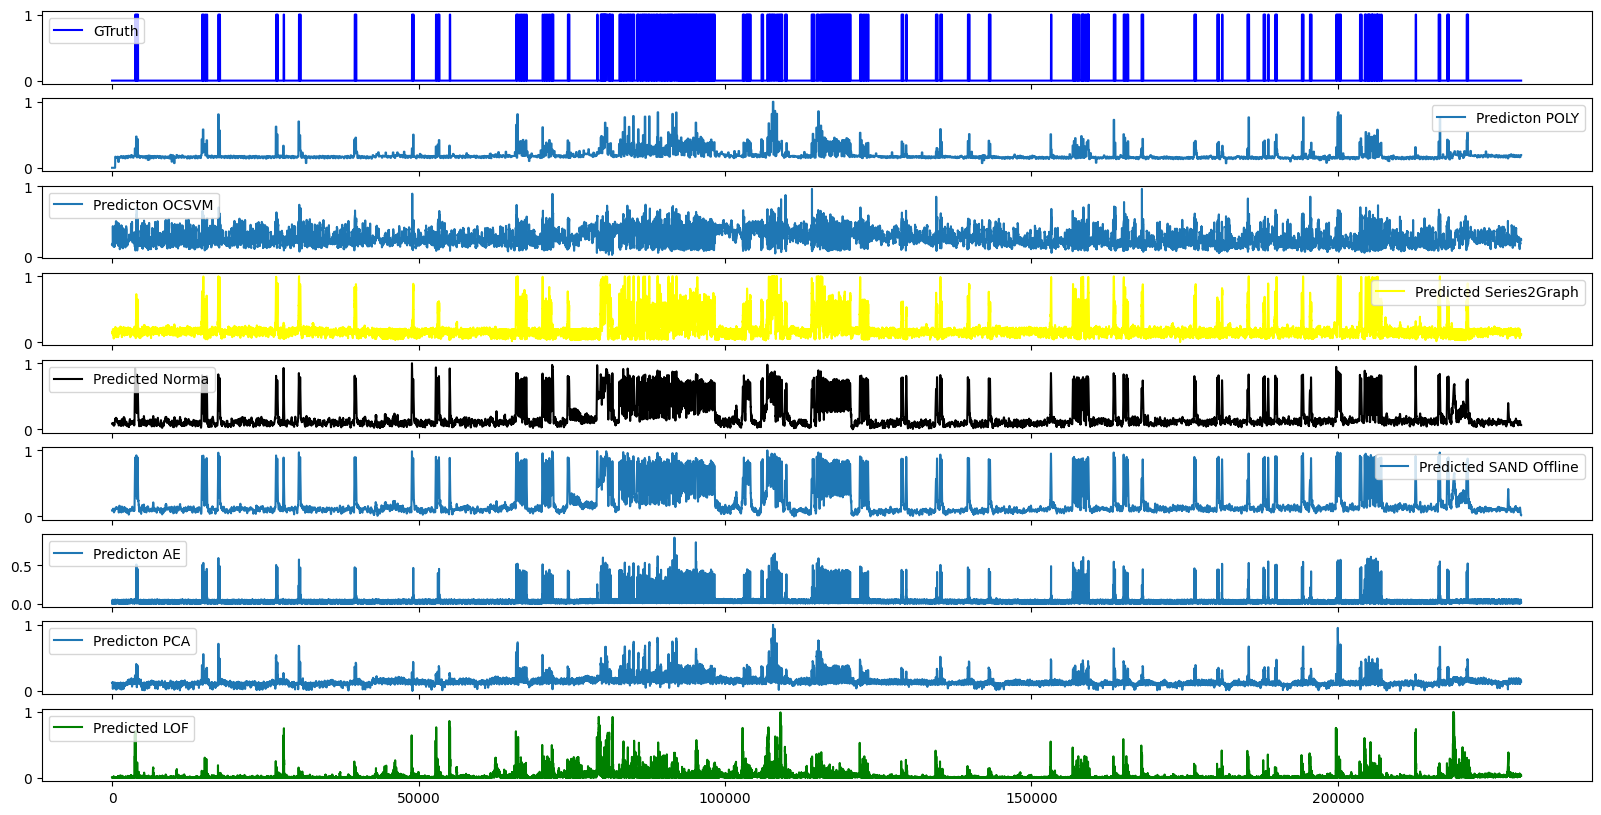

In [18]:
plotter(label, tsb_scores_dict_820=tsb_scores_dict)

### Labels compared with Static Threshold

In [22]:
y_pred_if = [1 if scr > 0.39 else 0 for scr in tsb_scores_dict['IF']]
y_pred_s2g = [1 if scr > 0.6 else 0 for scr in tsb_scores_dict['S2G']]
y_pred_norma = [1 if scr > 0.59 else 0 for scr in tsb_scores_dict['norma']]
y_pred_pca = [1 if scr > 0.41 else 0 for scr in tsb_scores_dict['PCA']]
y_pred_sand_off = [1 if scr > 0.5999 else 0 for scr in tsb_scores_dict['SAND_OFF']]
y_pred_poly = [1 if scr > 0.48 else 0 for scr in tsb_scores_dict['POLY']]
y_pred_ocsvm = [1 if scr > 0.59 else 0 for scr in tsb_scores_dict['OCSVM']]
y_pred_ae = [1 if scr > 0.19 else 0 for scr in tsb_scores_dict['AE']]
y_pred_lof = [1 if scr > 0.2 else 0 for scr in tsb_scores_dict['LOF']]

In [20]:
len(y_pred_if)

229900

In [23]:
y_pred_list_805 = [y_pred_if, y_pred_s2g, y_pred_norma, y_pred_pca, y_pred_sand_off, y_pred_poly, y_pred_ocsvm, y_pred_ae, y_pred_lof]

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

for pred in y_pred_list_805:
    prec = precision_score(label, pred)
    recall = recall_score(label, pred)
    f1 = f1_score(label, pred)

    print(f'Precision Score: {prec:.4f}  Recall: {recall:.4f}  f1_score: {f1:.4f}')

Precision Score: 0.6817  Recall: 0.2978  f1_score: 0.4145
Precision Score: 0.7390  Recall: 0.4351  f1_score: 0.5477
Precision Score: 0.6979  Recall: 0.6769  f1_score: 0.6873
Precision Score: 0.7071  Recall: 0.1978  f1_score: 0.3091
Precision Score: 0.6446  Recall: 0.7244  f1_score: 0.6822
Precision Score: 0.6355  Recall: 0.1927  f1_score: 0.2957
Precision Score: 0.8879  Recall: 0.0593  f1_score: 0.1111
Precision Score: 0.9878  Recall: 0.1807  f1_score: 0.3055
Precision Score: 0.3306  Recall: 0.0560  f1_score: 0.0958


In [75]:
ypred805_dict = {"IF": y_pred_if, "S2G": y_pred_s2g, "norma": y_pred_norma, "PCA": y_pred_pca, "SAND_OFF": y_pred_sand_off, "POLY": y_pred_poly, "OCSVM": y_pred_ocsvm, "AE": y_pred_ae}

In [76]:
import json

with open('../data/pred_labels_ecg805_50k.json', 'w') as file:
    json.dump(ypred805_dict, file)

In [22]:
y_pred_lof = [1 if scr > 0.1 else 0 for scr in tsb_scores_dict_820['LOF']]
y_pred_s2g = [1 if scr > 0.5 else 0 for scr in tsb_scores_dict_820['S2G']]
y_pred_norma = [1 if scr > 0.34 else 0 for scr in tsb_scores_dict_820['norma']]
y_pred_sand_on = [1 if scr > 0.61 else 0 for scr in tsb_scores_dict_820['SAND_ON']]
y_pred_sand_off = [1 if scr > 0.39 else 0 for scr in tsb_scores_dict_820['SAND_OFF']]
y_pred_ae = [1 if scr > 0.21 else 0 for scr in tsb_scores_dict_820['AE']]

In [43]:
labels_dict = {}

for model, scr in tsb_scores_dict.items():
    rg_pr, rg_rc, rg_f1, rg_prauc, adjusted_y_pred = adjusted_precision_recall_f1_auc(label, np.array(scr))
    labels_dict[model] = adjusted_y_pred.astype(int).tolist()
    print(f'Model: {model} Point Adjusted F1: {rg_f1:.4f}, Point Adjusted AUCpr: {rg_prauc:.4f}')

Model: IF Point Adjusted F1: 0.8675, Point Adjusted AUCpr: 0.8800
Model: S2G Point Adjusted F1: 0.8719, Point Adjusted AUCpr: 0.8766
Model: norma Point Adjusted F1: 0.9170, Point Adjusted AUCpr: 0.9302
Model: PCA Point Adjusted F1: 0.7805, Point Adjusted AUCpr: 0.7589
Model: SAND_OFF Point Adjusted F1: 0.9136, Point Adjusted AUCpr: 0.9383
Model: POLY Point Adjusted F1: 0.7593, Point Adjusted AUCpr: 0.6996
Model: OCSVM Point Adjusted F1: 0.8551, Point Adjusted AUCpr: 0.9076
Model: AE Point Adjusted F1: 0.9782, Point Adjusted AUCpr: 0.9893


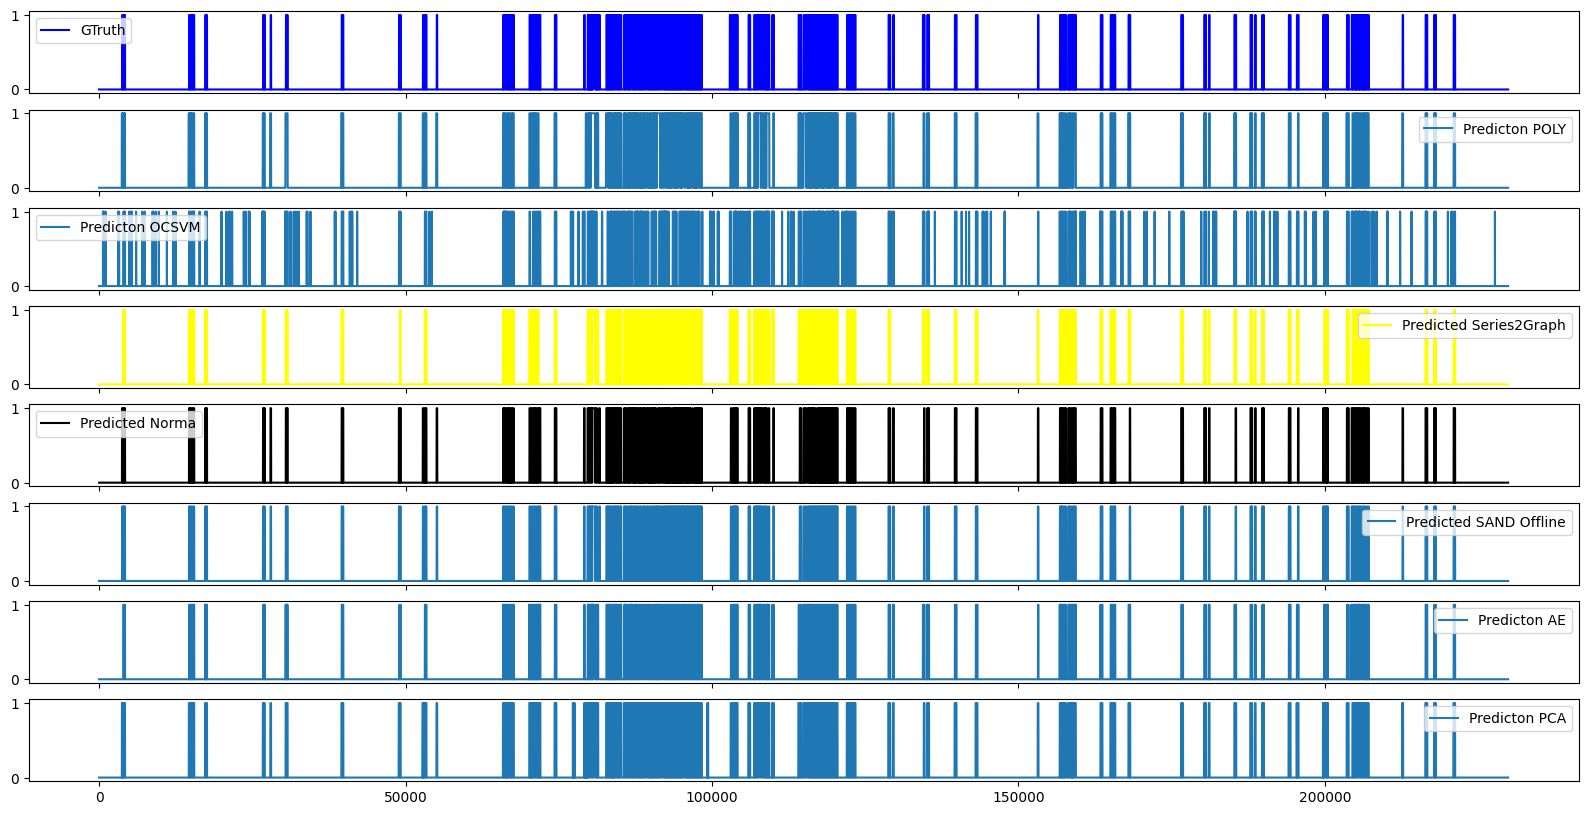

In [44]:
plotter(label, tsb_scores_dict_820=labels_dict)

In [45]:
import json

with open('../data/pred_labels_ecg14046_0_full.json', 'w') as file:
    json.dump(labels_dict, file)

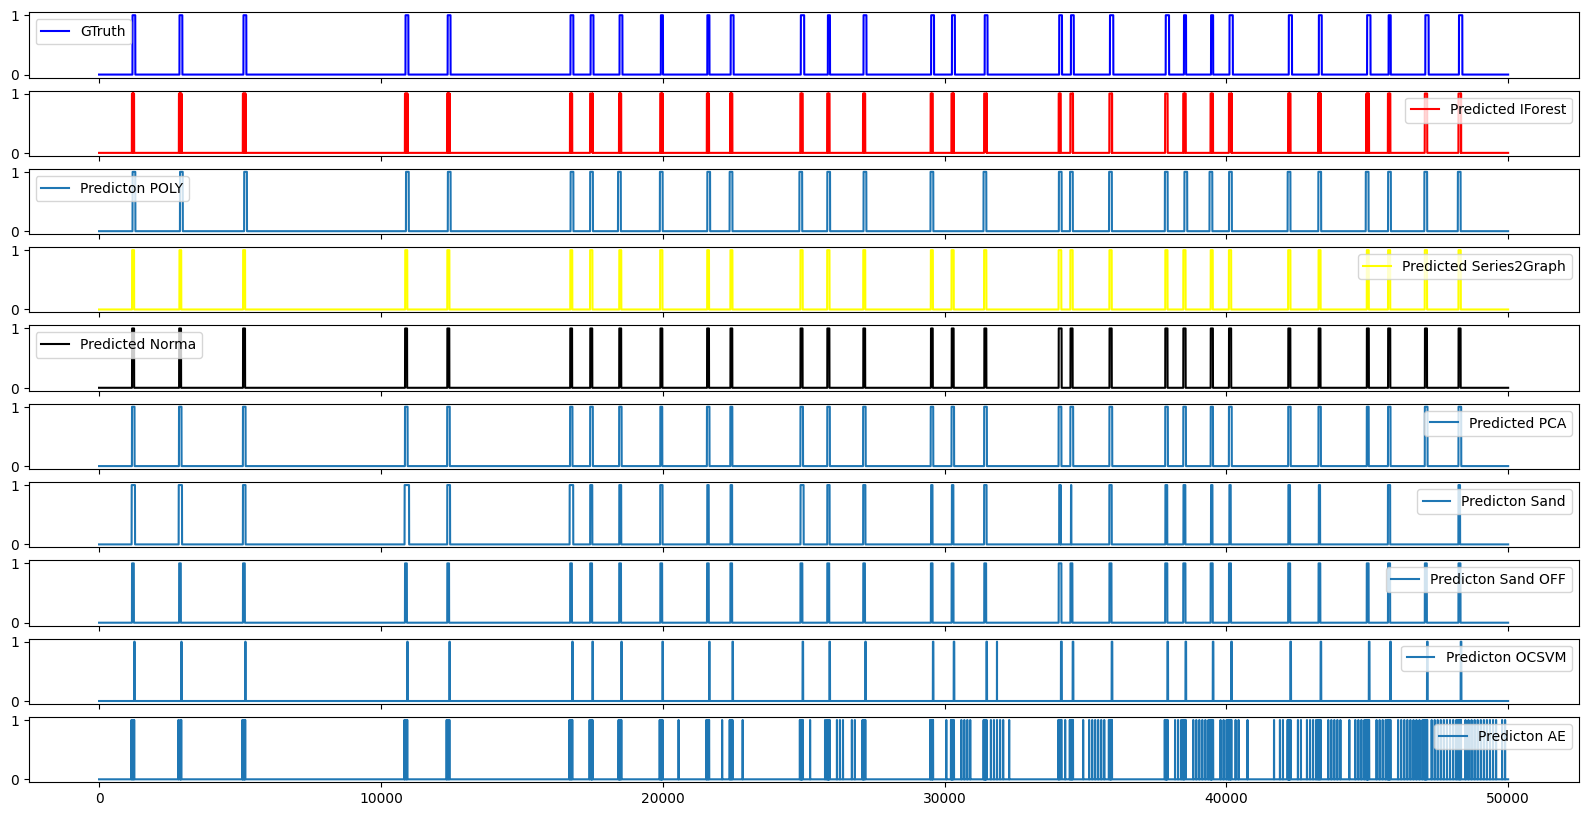

In [73]:
# ECG 805 Dataset with 9 detectors

fig, axs = plt.subplots(10, 1, sharex=True, figsize = (20, 10))
index = range(len(label))


axs[0].plot(index, label, color='blue', label='GTruth')
axs[1].plot(index, y_pred_if, color='red', label='Predicted IForest')
axs[2].plot(index, y_pred_poly, label='Predicton POLY')
axs[3].plot(index, y_pred_s2g, color='yellow', label='Predicted Series2Graph')
axs[4].plot(index, y_pred_norma, color='black', label='Predicted Norma')
axs[5].plot(index, y_pred_pca, label='Predicted PCA')
axs[6].plot(index, y_pred_sand_on, label='Predicton Sand')
axs[7].plot(index, y_pred_sand_off, label='Predicton Sand OFF')
axs[8].plot(index, y_pred_ocsvm, label='Predicton OCSVM')
axs[9].plot(index, y_pred_ae, label='Predicton AE')


axs[0].legend(loc='upper left')
axs[1].legend(loc='upper right')
axs[2].legend(loc='upper left')
axs[3].legend(loc='upper right')
axs[4].legend(loc='upper left')
axs[5].legend(loc='upper right')
axs[6].legend()
axs[7].legend()
axs[8].legend()
axs[9].legend()

plt.show()

In [74]:
# Point-Wise Precision, Recall and F1

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, auc, precision_recall_curve

for i, y_pred in enumerate(y_pred_list_805):
    prec = precision_score(label, y_pred)
    recall = recall_score(label, y_pred)
    f1 = f1_score(label, y_pred)
    print(f'Model: {i+1} 1. Precision Score: {prec:.4f}  2. Recall: {recall:.4f}  3. f1_score: {f1:.4f}')

Model: 1 1. Precision Score: 0.7469  2. Recall: 0.5909  3. f1_score: 0.6598
Model: 2 1. Precision Score: 0.7991  2. Recall: 0.6087  3. f1_score: 0.6911
Model: 3 1. Precision Score: 0.8127  2. Recall: 0.5922  3. f1_score: 0.6851
Model: 4 1. Precision Score: 0.8032  2. Recall: 0.7214  3. f1_score: 0.7601
Model: 5 1. Precision Score: 0.8000  2. Recall: 0.5658  3. f1_score: 0.6628
Model: 6 1. Precision Score: 0.7660  2. Recall: 0.5215  3. f1_score: 0.6205
Model: 7 1. Precision Score: 0.7259  2. Recall: 0.6887  3. f1_score: 0.7068
Model: 8 1. Precision Score: 0.9634  2. Recall: 0.1913  3. f1_score: 0.3193
Model: 9 1. Precision Score: 0.5863  2. Recall: 0.2895  3. f1_score: 0.3876


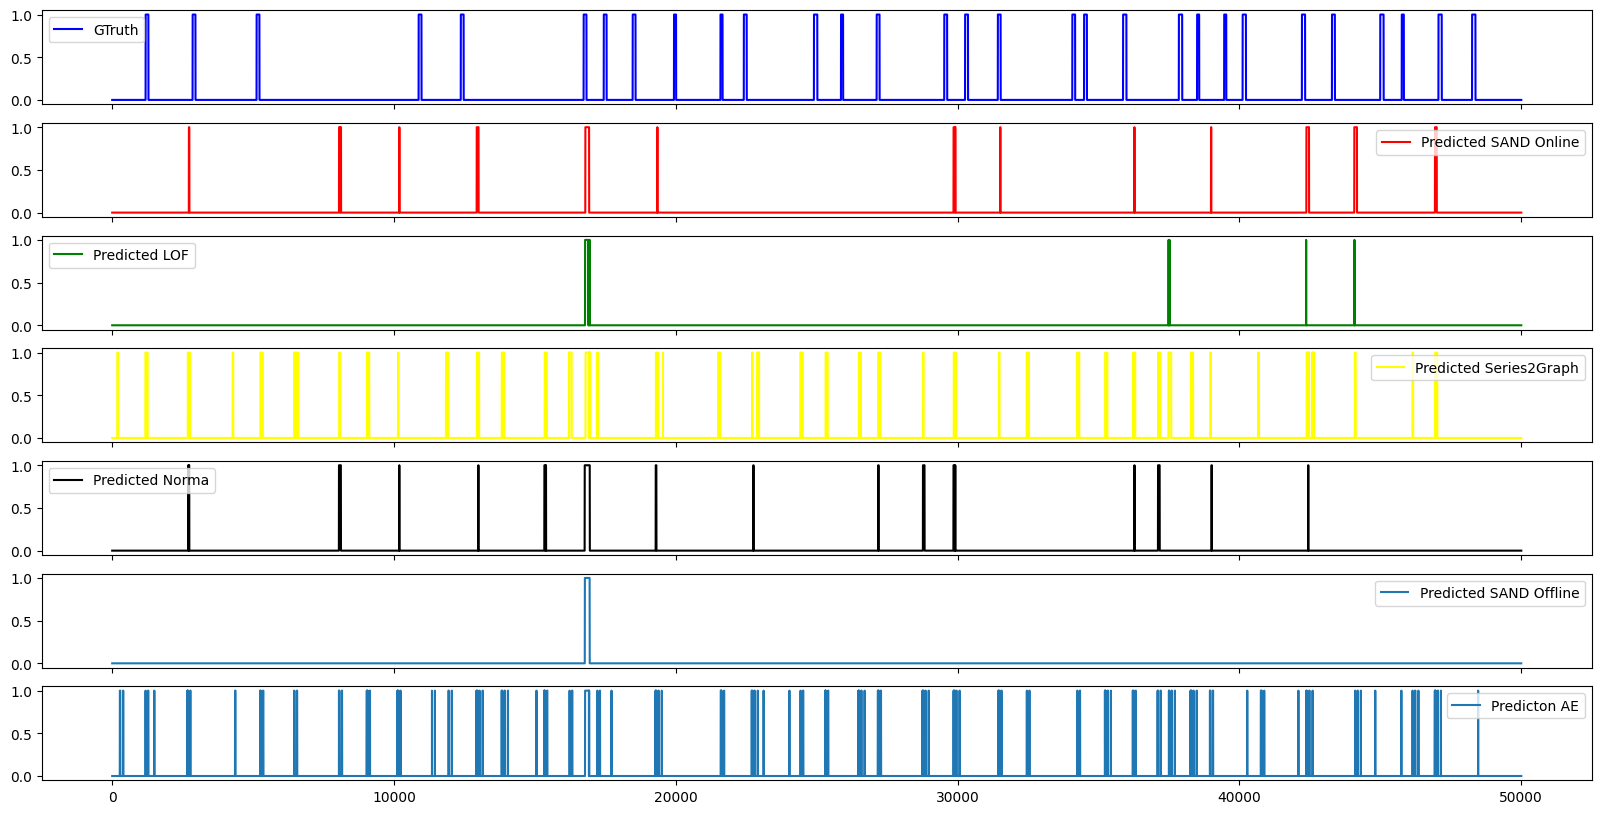

In [17]:
fig, axs = plt.subplots(7, 1, sharex=True, figsize = (20, 10))
index = range(len(label))


axs[0].plot(index, label, color='blue', label='GTruth')
axs[1].plot(index, y_pred_sand_on, color='red', label='Predicted SAND Online')
axs[2].plot(index, y_pred_lof, color='green', label='Predicted LOF')
axs[3].plot(index, y_pred_s2g, color='yellow', label='Predicted Series2Graph')
axs[4].plot(index, y_pred_norma, color='black', label='Predicted Norma')
axs[5].plot(index, y_pred_sand_off, label='Predicted SAND Offline')
axs[6].plot(index, y_pred_ae, label='Predicton AE')

axs[0].legend(loc='upper left')
axs[1].legend(loc='upper right')
axs[2].legend(loc='upper left')
axs[3].legend(loc='upper right')
axs[4].legend(loc='upper left')
axs[5].legend(loc='upper right')
axs[6].legend()

plt.show()

### Labels Compared with Dynamic Thresholds

In [47]:
len(tsb_scores_dict['SAND_OFF'])

47497

In [48]:
def detect_anomalies(data, window_size, threshold_factor):
    anomalies = []
    overlap = window_size
    for i in range(0, len(data), overlap):
        if i + window_size <= len(data):
            window = data[i:i+window_size]
        else:
            window = data[i:]
        mean = np.mean(window)
        std_dev = np.std(window)
        threshold = mean + threshold_factor * std_dev
        anomaly_score = [1 if val > threshold else 0 for val in window]
        anomalies.extend(anomaly_score)
        
    return anomalies

In [344]:
dyn_label_sand = detect_anomalies(tsb_scores_dict['norma'], window_size=1000, threshold_factor=1.5)

In [ ]:
def get_range_proba(predict, label, delay=7):
    splits = np.where(label[1:] != label[:-1])[0] + 1
    is_anomaly = label[0] == 1
    new_predict = np.array(predict)
    pos = 0

    for sp in splits:
        if is_anomaly:
            if 1 in predict[pos:min(pos + delay + 1, sp)]:
                new_predict[pos: sp] = 1
            else:
                new_predict[pos: sp] = 0
        is_anomaly = not is_anomaly
        pos = sp
    sp = len(label)

    if is_anomaly:  # anomaly in the end
        if 1 in predict[pos: min(pos + delay + 1, sp)]:
            new_predict[pos: sp] = 1
        else:
            new_predict[pos: sp] = 0

    return new_predict

In [391]:
dynamic_dict = {}

for key, value in tsb_scores_dict.items():
    if key == 'IF':
        dynamic_pred = detect_anomalies(value, window_size=10000, threshold_factor=2.5)
    
    elif key == 'POLY':
        dynamic_pred = detect_anomalies(value, window_size=10000, threshold_factor=1.1)
    else:
        dynamic_pred = detect_anomalies(value, window_size=10000, threshold_factor=1.75)
    
    dynamic_pred = get_range_proba(dynamic_pred, label_dodgers, delay=10)
    dynamic_dict[key] = np.array(dynamic_pred).reshape(-1, 1)

In [392]:
dynamic_dict['IF'].shape

(47497, 1)

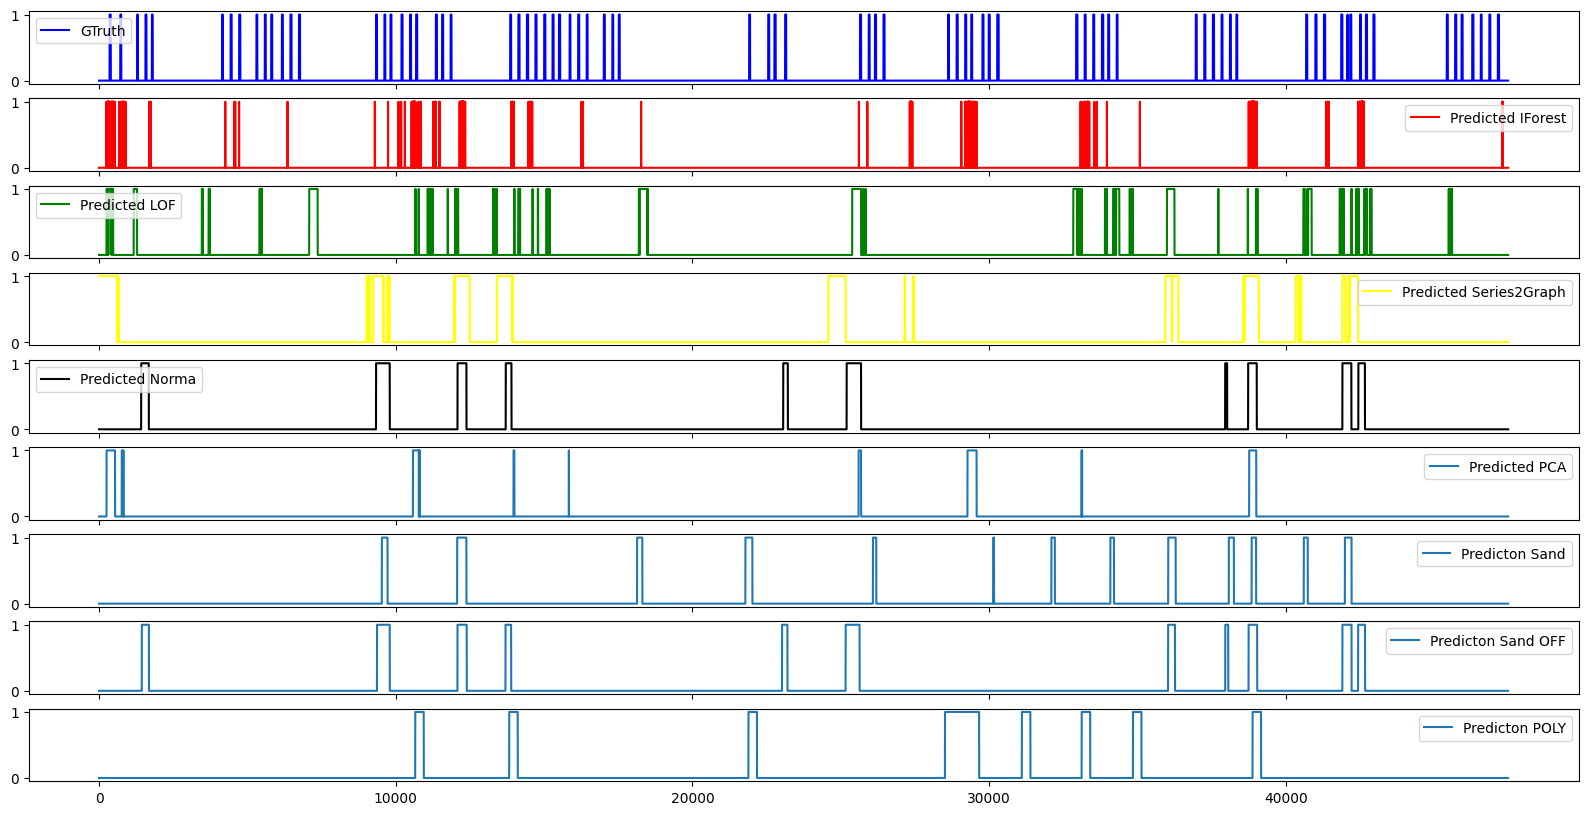

In [393]:
fig, axs = plt.subplots(9, 1, sharex=True, figsize = (20, 10))
index = range(len(label_dodgers))


axs[0].plot(index, label_dodgers, color='blue', label='GTruth')
axs[1].plot(index, dynamic_dict['IF'], color='red', label='Predicted IForest')
axs[2].plot(index, dynamic_dict['LOF'], color='green', label='Predicted LOF')
axs[3].plot(index, dynamic_dict['S2G'], color='yellow', label='Predicted Series2Graph')
axs[4].plot(index, dynamic_dict['norma'], color='black', label='Predicted Norma')
axs[5].plot(index, dynamic_dict['PCA'], label='Predicted PCA')
axs[6].plot(index, dynamic_dict['SAND_ON'], label='Predicton Sand')
axs[7].plot(index, dynamic_dict['SAND_OFF'], label='Predicton Sand OFF')
axs[8].plot(index, dynamic_dict['POLY'], label='Predicton POLY')

axs[0].legend(loc='upper left')
axs[1].legend(loc='upper right')
axs[2].legend(loc='upper left')
axs[3].legend(loc='upper right')
axs[4].legend(loc='upper left')
axs[5].legend(loc='upper right')
axs[6].legend()
axs[7].legend()
axs[8].legend()

plt.show()

In [394]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, auc, precision_recall_curve
for key, value in dynamic_dict.items():
    prec = precision_score(label_dodgers, value)
    recall = recall_score(label_dodgers, value)
    f1 = f1_score(label_dodgers, value)
    print(f'Model: {key} 1. Precision Score: {prec:.4f}  2. Recall: {recall:.4f}  3. f1_score: {f1:.4f}')

Model: IF 1. Precision Score: 0.1292  2. Recall: 0.0354  3. f1_score: 0.0556
Model: LOF 1. Precision Score: 0.0920  2. Recall: 0.0963  3. f1_score: 0.0941
Model: S2G 1. Precision Score: 0.0333  2. Recall: 0.0520  3. f1_score: 0.0406
Model: norma 1. Precision Score: 0.1000  2. Recall: 0.1011  3. f1_score: 0.1006
Model: PCA 1. Precision Score: 0.1186  2. Recall: 0.0528  3. f1_score: 0.0731
Model: SAND_ON 1. Precision Score: 0.0936  2. Recall: 0.0772  3. f1_score: 0.0846
Model: SAND_OFF 1. Precision Score: 0.0685  2. Recall: 0.0757  3. f1_score: 0.0719
Model: POLY 1. Precision Score: 0.0827  2. Recall: 0.0967  3. f1_score: 0.0892


In [390]:
for detector in tsb_scores_dict:
    rock = roc_auc_score(label_dodgers, tsb_scores_dict[detector])
    precision, recall, _ = precision_recall_curve(label_dodgers, tsb_scores_dict[detector])
    auc_pr = auc(recall, precision)
    print(f'{detector} 3. ROC_AUC Value: {rock} 4. AUC_PR: {auc_pr}')

IF 3. ROC_AUC Value: 0.6028921684547881 4. AUC_PR: 0.07836429539069104
LOF 3. ROC_AUC Value: 0.5346920793957064 4. AUC_PR: 0.06406531646455314
S2G 3. ROC_AUC Value: 0.519521132377618 4. AUC_PR: 0.05691181077631396
norma 3. ROC_AUC Value: 0.6701948918250626 4. AUC_PR: 0.08714352092391527
PCA 3. ROC_AUC Value: 0.5607210910822136 4. AUC_PR: 0.06979234881430255
SAND_ON 3. ROC_AUC Value: 0.5931193032345023 4. AUC_PR: 0.07136622962982149
SAND_OFF 3. ROC_AUC Value: 0.6295605154877053 4. AUC_PR: 0.07814829179374021
POLY 3. ROC_AUC Value: 0.5889687540890313 4. AUC_PR: 0.07709440799355671
